# Análise de ERD (Event-Related Desynchronization)

Este notebook processa arquivos de dados EEG (formato OpenBCI CSV), filtra os dados na banda de 8-30 Hz, aplica a transformada de Hilbert para extrair o envelope e calcula a potência e o ERD para eventos T1 (mão esquerda) e T2 (mão direita).

A análise é restrita aos arquivos de "Run" com número par (ex: R04, R08, etc.).

In [15]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
import mne

# Configurações
DATA_ROOT = r'C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data'
FS = 125.0  # Frequência de amostragem do OpenBCI
LOWCUT = 8.0
HIGHCUT = 30.0
ORDER = 4

# Intervalo de época (em segundos) em torno do evento
T_PRE = 2.0
T_POST = 4.0
BASELINE_WINDOW = (-1.5, -0.5)  # Segundos antes do evento para baseline

# Canais EEG (OpenBCI Cyton+Daisy tem 16 canais)
CHANNELS = [f'EXG Channel {i}' for i in range(16)]

In [16]:
# Funções de Normalização de Dados EEG
from sklearn.preprocessing import StandardScaler, MinMaxScaler

def normalize_eeg_data(eeg_data, method='zscore', per_channel=True):
    """
    Normaliza os dados EEG usando diferentes métodos.
    
    Parâmetros:
    -----------
    eeg_data : ndarray
        Dados EEG com shape (n_samples, n_channels)
    method : str
        'zscore': Normalização Z-score (média=0, std=1)
        'minmax': Normalização Min-Max (0-1)
        'robust': Normalização robusta usando mediana e IQR
    per_channel : bool
        Se True, normaliza cada canal independentemente
        Se False, normaliza toda a matriz de uma vez
    
    Retorna:
    --------
    normalized_data : ndarray
        Dados normalizados com mesma shape
    scaler : object
        Objeto scaler para aplicar a mesma normalização a novos dados
    """
    
    if per_channel:
        # Normalizar cada canal independentemente
        normalized_data = np.zeros_like(eeg_data, dtype=np.float32)
        
        if method == 'zscore':
            scaler = StandardScaler()
            for ch in range(eeg_data.shape[1]):
                normalized_data[:, ch] = scaler.fit_transform(eeg_data[:, ch].reshape(-1, 1)).flatten()
                
        elif method == 'minmax':
            scaler = MinMaxScaler(feature_range=(0, 1))
            for ch in range(eeg_data.shape[1]):
                normalized_data[:, ch] = scaler.fit_transform(eeg_data[:, ch].reshape(-1, 1)).flatten()
                
        elif method == 'robust':
            from sklearn.preprocessing import RobustScaler
            scaler = RobustScaler()
            for ch in range(eeg_data.shape[1]):
                normalized_data[:, ch] = scaler.fit_transform(eeg_data[:, ch].reshape(-1, 1)).flatten()
    else:
        # Normalizar toda a matriz
        if method == 'zscore':
            scaler = StandardScaler()
        elif method == 'minmax':
            scaler = MinMaxScaler(feature_range=(0, 1))
        elif method == 'robust':
            from sklearn.preprocessing import RobustScaler
            scaler = RobustScaler()
        
        normalized_data = scaler.fit_transform(eeg_data)
    
    return normalized_data, scaler

# Informações sobre normalização
print("="*70)
print("MÉTODOS DE NORMALIZAÇÃO DISPONÍVEIS")
print("="*70)
print("\n1. Z-score (StandardScaler):")
print("   - Normaliza para média=0 e desvio padrão=1")
print("   - Ideal para algoritmos que assumem distribuição normal")
print("   - Recomendado para análises estatísticas")
print("\n2. Min-Max (MinMaxScaler):")
print("   - Normaliza para intervalo [0, 1]")
print("   - Preserva a distribuição dos dados")
print("   - Ideal para neural networks")
print("\n3. Robust Scaler:")
print("   - Menos sensível a outliers")
print("   - Usa mediana e IQR")
print("   - Recomendado quando há ruído significativo")
print("\nUse per_channel=True para normalizar cada canal independentemente")
print("Use per_channel=False para normalizar toda a matriz conjuntamente")
print("="*70)

MÉTODOS DE NORMALIZAÇÃO DISPONÍVEIS

1. Z-score (StandardScaler):
   - Normaliza para média=0 e desvio padrão=1
   - Ideal para algoritmos que assumem distribuição normal
   - Recomendado para análises estatísticas

2. Min-Max (MinMaxScaler):
   - Normaliza para intervalo [0, 1]
   - Preserva a distribuição dos dados
   - Ideal para neural networks

3. Robust Scaler:
   - Menos sensível a outliers
   - Usa mediana e IQR
   - Recomendado quando há ruído significativo

Use per_channel=True para normalizar cada canal independentemente
Use per_channel=False para normalizar toda a matriz conjuntamente


In [17]:
def butter_bandpass(lowcut, highcut, fs, order=5):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data, axis=0)
    return y

def get_envelope(data):
    analytic_signal = hilbert(data, axis=0)
    amplitude_envelope = np.abs(analytic_signal)
    return amplitude_envelope

def extract_epochs(power_data, indices, t_pre=T_PRE, t_post=T_POST, fs=FS):
    """
    Extrai épocas (trials) em torno dos índices de eventos.
    
    Parâmetros:
    -----------
    power_data : ndarray
        Dados de potência com shape (n_samples, n_channels)
    indices : list
        Índices dos eventos
    t_pre, t_post : float
        Tempo antes e depois do evento (em segundos)
    fs : float
        Frequência de amostragem
    
    Retorna:
    --------
    epochs : ndarray
        Shape (n_events, n_pre + n_post, n_channels)
    """
    n_pre = int(t_pre * fs)
    n_post = int(t_post * fs)
    n_channels = power_data.shape[1]
    
    epochs = []
    for idx in indices:
        start = idx - n_pre
        end = idx + n_post
        
        if start >= 0 and end <= len(power_data):
            epoch = power_data[start:end, :]
            epochs.append(epoch)
    
    if len(epochs) > 0:
        return np.array(epochs)
    else:
        return np.array([]).reshape(0, n_pre + n_post, n_channels)

def calculate_erd(epochs, baseline_window=BASELINE_WINDOW, t_pre=T_PRE, fs=FS):
    """
    Calcula ERD (Event-Related Desynchronization) em dB.
    
    Parâmetros:
    -----------
    epochs : ndarray
        Shape (n_trials, n_samples, n_channels)
    baseline_window : tuple
        Intervalo de baseline em segundos (relativo ao evento)
    t_pre : float
        Tempo pré-evento em segundos
    fs : float
        Frequência de amostragem
    
    Retorna:
    --------
    erd_db : ndarray
        ERD em dB, shape (n_samples, n_channels)
    avg_power : ndarray
        Potência média por canal, shape (n_samples, n_channels)
    """
    # Calcular potência média sobre trials
    avg_power = np.mean(epochs, axis=0)  # Shape: (n_samples, n_channels)
    
    # Calcular potência de baseline
    baseline_start = int((baseline_window[0] + t_pre) * fs)
    baseline_end = int((baseline_window[1] + t_pre) * fs)
    baseline_power = np.mean(avg_power[baseline_start:baseline_end, :], axis=0)
    
    # Calcular ERD% = 10 * log10(power / baseline_power)
    erd_db = np.zeros_like(avg_power)
    for ch in range(avg_power.shape[1]):
        if baseline_power[ch] > 0:
            erd_db[:, ch] = 10 * np.log10(avg_power[:, ch] / baseline_power[ch])
        else:
            erd_db[:, ch] = 0
    
    return erd_db, avg_power

def find_files(root_dir):
    # Procura recursivamente por arquivos CSV
    all_files = glob.glob(os.path.join(root_dir, '**', '*_csv_openbci.csv'), recursive=True)
    
    # Filtra apenas os que terminam em número impar no identificador de Run (ex: R01, R03, etc.)
    # Padrão esperado: SxxxRxx_csv_openbci.csv
    valid_files = []
    pattern = re.compile(r'R(\d+)_csv_openbci\.csv$')
    
    for f in all_files:
        match = pattern.search(f)
        if match:
            run_num = int(match.group(1))
            if run_num % 2 != 0:
                valid_files.append(f)
    
    return valid_files

def load_and_process_file(filepath, normalize=True, normalization_method='zscore'):
    """
    Carrega e processa arquivo EEG.
    
    Parâmetros:
    -----------
    filepath : str
        Caminho do arquivo CSV
    normalize : bool
        Se True, aplica normalização antes do filtro
    normalization_method : str
        Método de normalização: 'zscore', 'minmax', 'robust'
    """
    print(f"Processando: {filepath}")
    
    # Carregar CSV, ignorando linhas de comentário (%)
    # O cabeçalho está na linha que não começa com %
    with open(filepath, 'r') as f:
        lines = f.readlines()
    
    header_line = 0
    for i, line in enumerate(lines):
        if not line.startswith('%'):
            header_line = i
            break
            
    df = pd.read_csv(filepath, skiprows=header_line)
    
    # Extrair dados EEG
    eeg_data = df[CHANNELS].values
    
    # NORMALIZAÇÃO (novo passo importante!)
    if normalize:
        print(f"  ├─ Normalizando dados com método: {normalization_method}")
        eeg_data, _ = normalize_eeg_data(eeg_data, method=normalization_method, per_channel=True)
        print(f"  └─ ✓ Normalização concluída")
    
    # Filtrar 8-30 Hz
    eeg_filtered = butter_bandpass_filter(eeg_data, LOWCUT, HIGHCUT, FS, ORDER)
    
    # Envelope (Hilbert)
    envelope = get_envelope(eeg_filtered)
    
    # Potência (Envelope ao quadrado)
    power = envelope ** 2
    
    # Extrair marcadores
    # A coluna 'Annotations' contém strings como 'T0', 'T1', 'T2'
    # Vamos pegar os índices onde T1 ou T2 aparecem
    # Assumindo que o marcador aparece apenas no início do evento ou dura algum tempo
    # Vamos pegar a transição para T1 ou T2
    
    annotations = df['Annotations'].fillna('').values
    
    events = {'T1': [], 'T2': []}
    
    # Detectar bordas de subida dos eventos
    for i in range(1, len(annotations)):
        curr = str(annotations[i]).strip()
        prev = str(annotations[i-1]).strip()
        
        if curr in ['T1', 'T2'] and curr != prev:
            events[curr].append(i)
            
    return power, events

Encontrados 147 arquivos válidos.
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R03_csv_openbci.csv
  ├─ Normalizando dados com método: zscore
  └─ ✓ Normalização concluída
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R07_csv_openbci.csv
  ├─ Normalizando dados com método: zscore
  └─ ✓ Normalização concluída
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R11_csv_openbci.csv
  ├─ Normalizando dados com método: zscore
  └─ ✓ Normalização concluída
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb\1.0.0\S002\S002R03_csv_openbci.csv
  ├─ Normalizando dados com método: zscore
  └─ ✓ Normalização concluída
Processando: C:\Users\Chari\Documents\dev\BrainBridge\tools\downloader\data\MNE-eegbci-data\files\eegmmidb

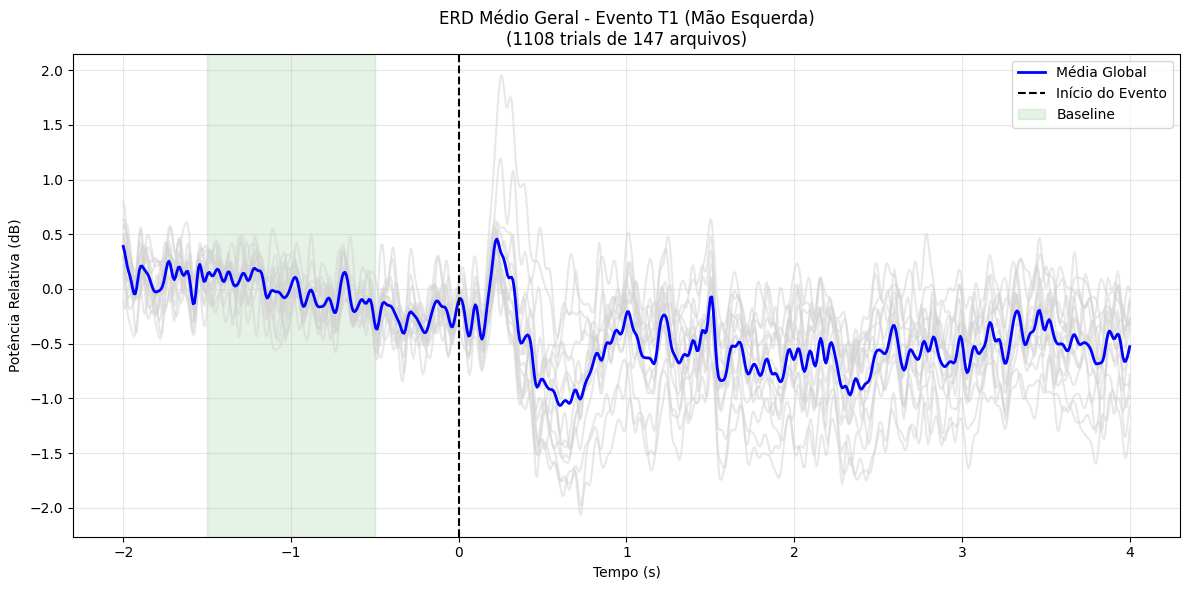

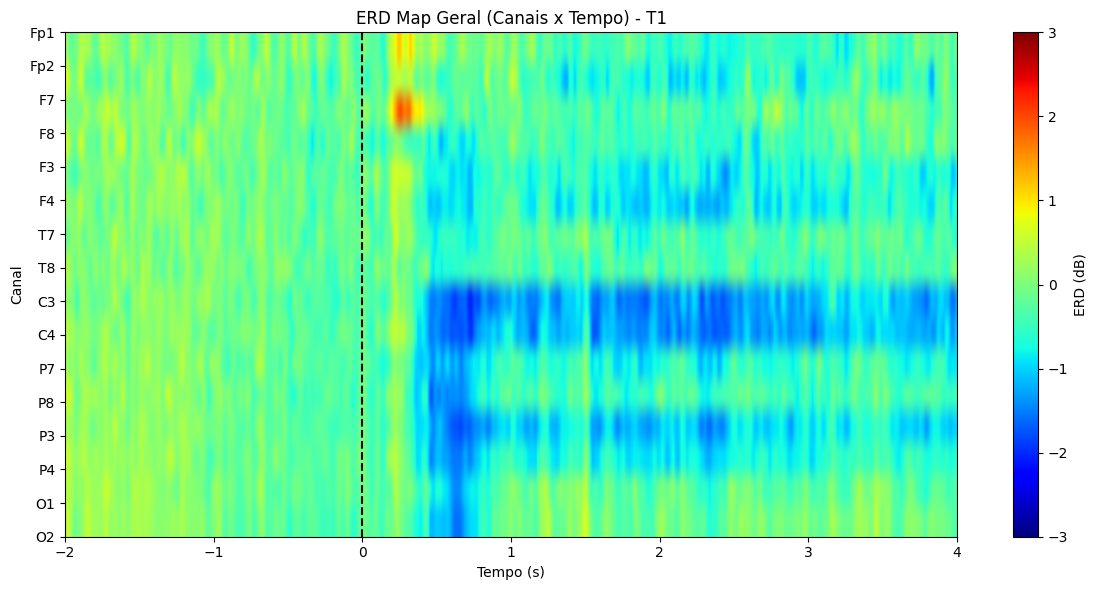

Processando T2: Total de 1097 trials acumulados.


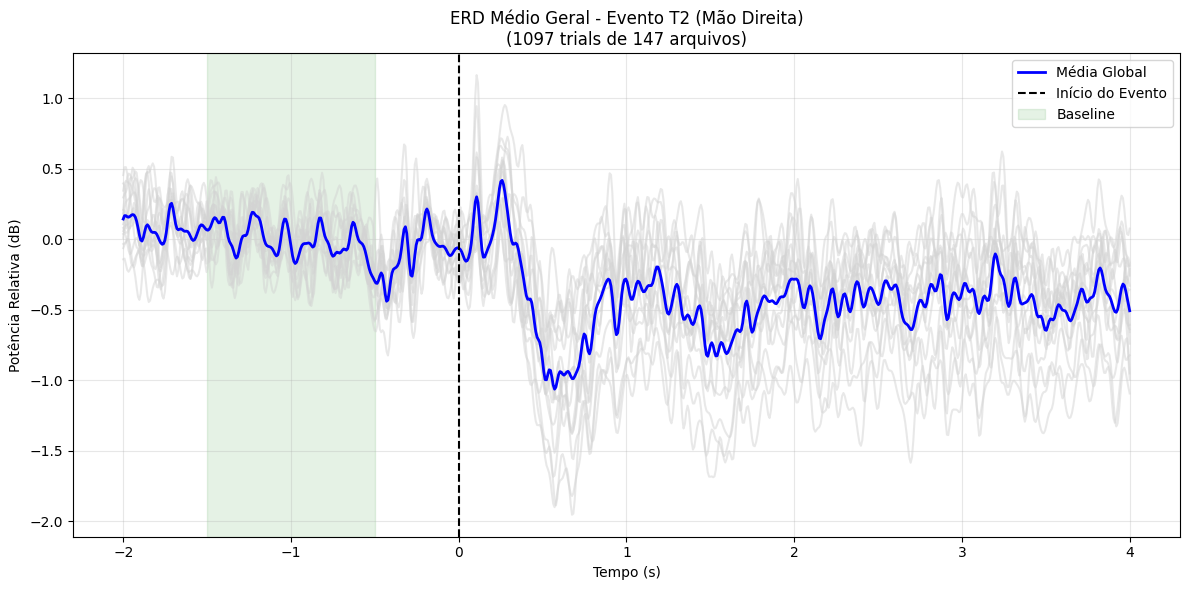

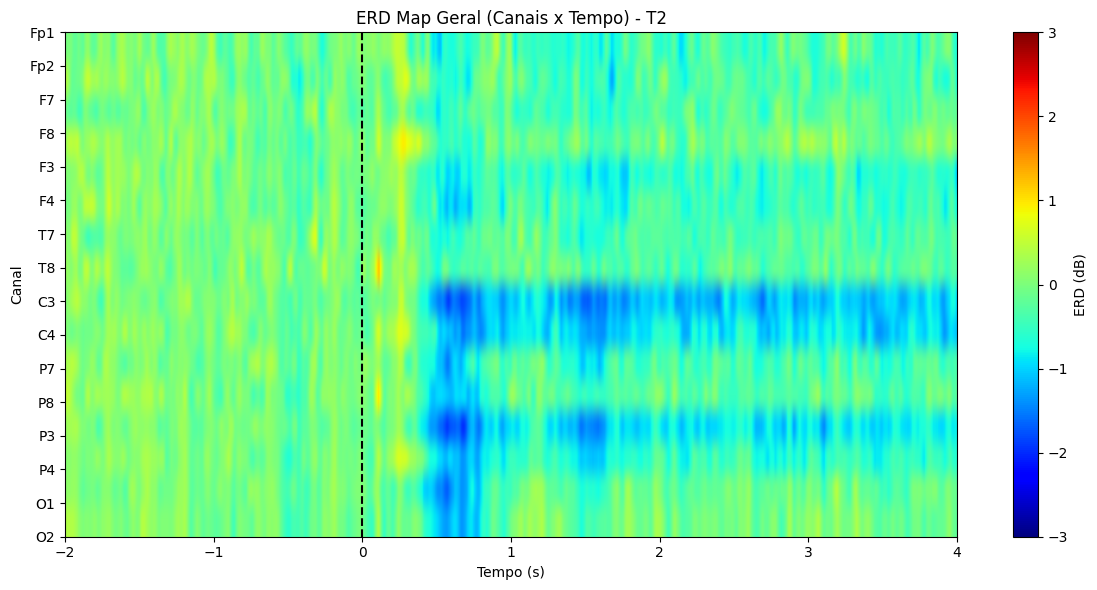

In [18]:
# Execução Principal
files = find_files(DATA_ROOT)
print(f"Encontrados {len(files)} arquivos válidos.")

all_epochs = {'T1': [], 'T2': []}

for f in files:
    try:
        power_data, events = load_and_process_file(f)
        
        for event_type in ['T1', 'T2']:
            indices = events[event_type]
            if not indices:
                continue
                
            epochs = extract_epochs(power_data, indices)
            if len(epochs) > 0:
                all_epochs[event_type].append(epochs)
    except Exception as e:
        print(f"Erro ao processar {f}: {e}")

# Processar e plotar acumulado
n_pre = int(T_PRE * FS)
n_post = int(T_POST * FS)
time_axis = np.linspace(-T_PRE, T_POST, n_pre + n_post)

for event_type in ['T1', 'T2']:
    epoch_list = all_epochs[event_type]
    
    if not epoch_list:
        print(f"Nenhum dado encontrado para {event_type}")
        continue
        
    # Concatenar todos os trials de todos os arquivos
    # epoch_list é uma lista de arrays (n_trials, n_samples, n_channels)
    combined_epochs = np.concatenate(epoch_list, axis=0)
    
    print(f"Processando {event_type}: Total de {combined_epochs.shape[0]} trials acumulados.")
    
    erd_db, avg_power = calculate_erd(combined_epochs)
    
    if erd_db is None:
        continue
        
    # Plotar
    plt.figure(figsize=(12, 6))
    
    # Plotar o ERD médio de todos os canais (linha grossa) e canais individuais (linhas finas)
    plt.plot(time_axis, erd_db, color='lightgray', alpha=0.5)
    plt.plot(time_axis, np.mean(erd_db, axis=1), color='blue', linewidth=2, label='Média Global')
    
    plt.axvline(0, color='k', linestyle='--', label='Início do Evento')
    plt.axvspan(BASELINE_WINDOW[0], BASELINE_WINDOW[1], color='green', alpha=0.1, label='Baseline')
    
    plt.title(f'ERD Médio Geral - Evento {event_type} (Mão {"Esquerda" if event_type == "T1" else "Direita"})\n({combined_epochs.shape[0]} trials de {len(files)} arquivos)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Potência Relativa (dB)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Opcional: Plotar mapa de calor (Canais x Tempo)
    plt.figure(figsize=(12, 6))
    plt.imshow(erd_db.T, aspect='auto', extent=[-T_PRE, T_POST, 15, 0], cmap='jet', vmin=-3, vmax=3)
    plt.colorbar(label='ERD (dB)')
    plt.title(f'ERD Map Geral (Canais x Tempo) - {event_type}')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Canal')
    
    # Nomes dos canais
    channel_names = ['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'P7', 'P8', 'P3', 'P4', 'O1', 'O2']
    plt.yticks(range(16), channel_names)
    
    plt.axvline(0, color='k', linestyle='--')
    plt.tight_layout()
    plt.show()


ANÁLISE ERD% = (Baseline - Activity) / Baseline

T1: 1108 trials
Baseline R shape: (16,)
ERD% calculated, shape: (750, 16)
R (Baseline) média por canal: 0.264874
A (Activity) média geral: 0.243225


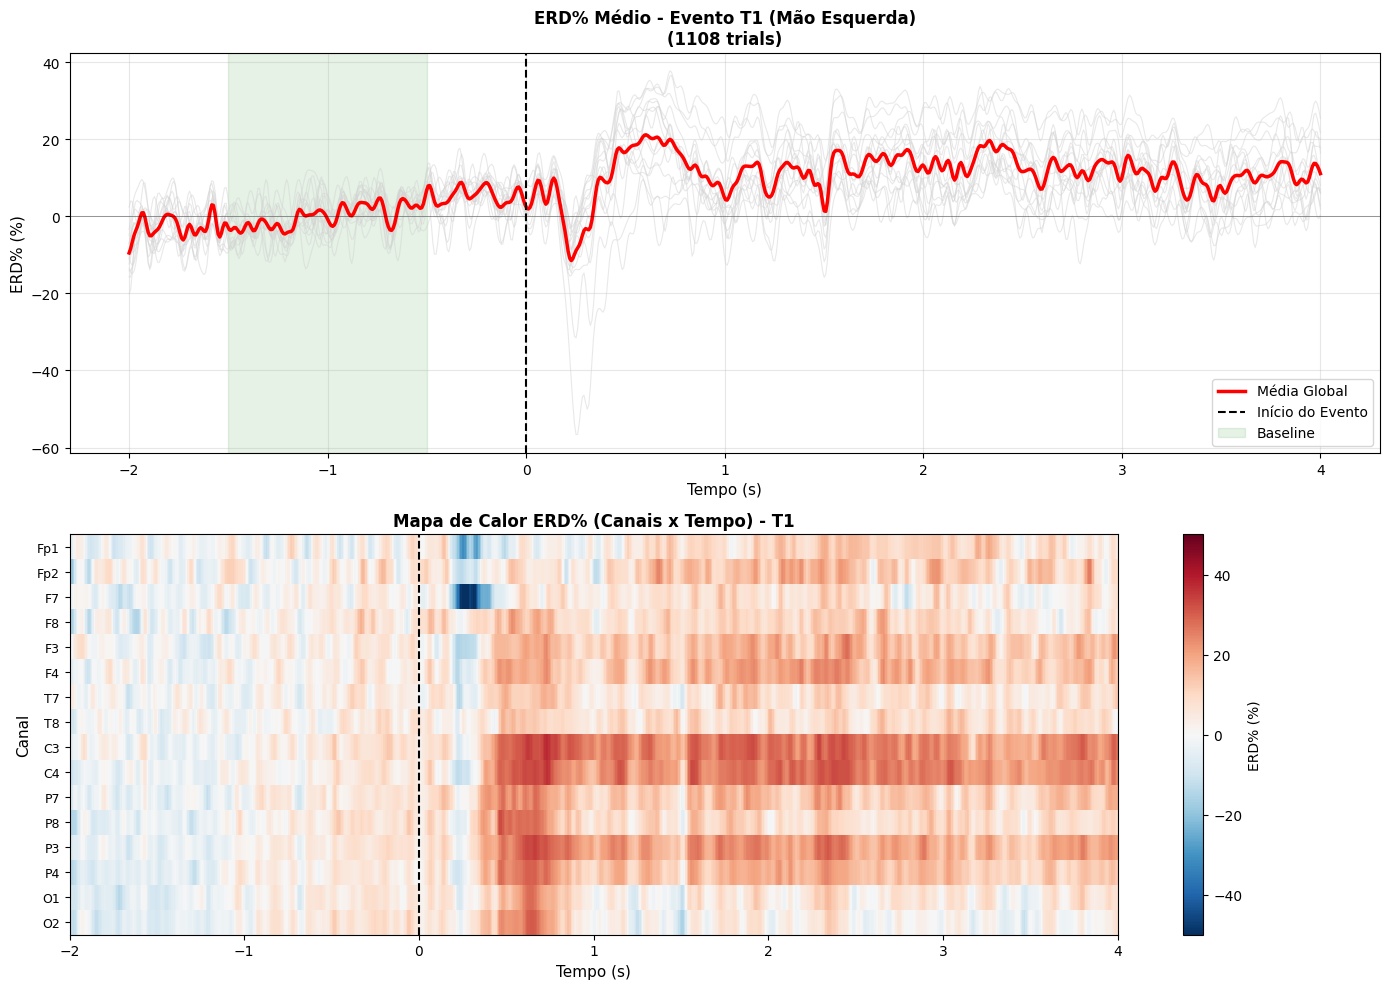

ERD% Média Global: 7.78%
ERD% Min: -56.67%
ERD% Max: 37.82%
ERD% Std: 9.80%

T2: 1097 trials
Baseline R shape: (16,)
ERD% calculated, shape: (750, 16)
R (Baseline) média por canal: 0.262491
A (Activity) média geral: 0.245436


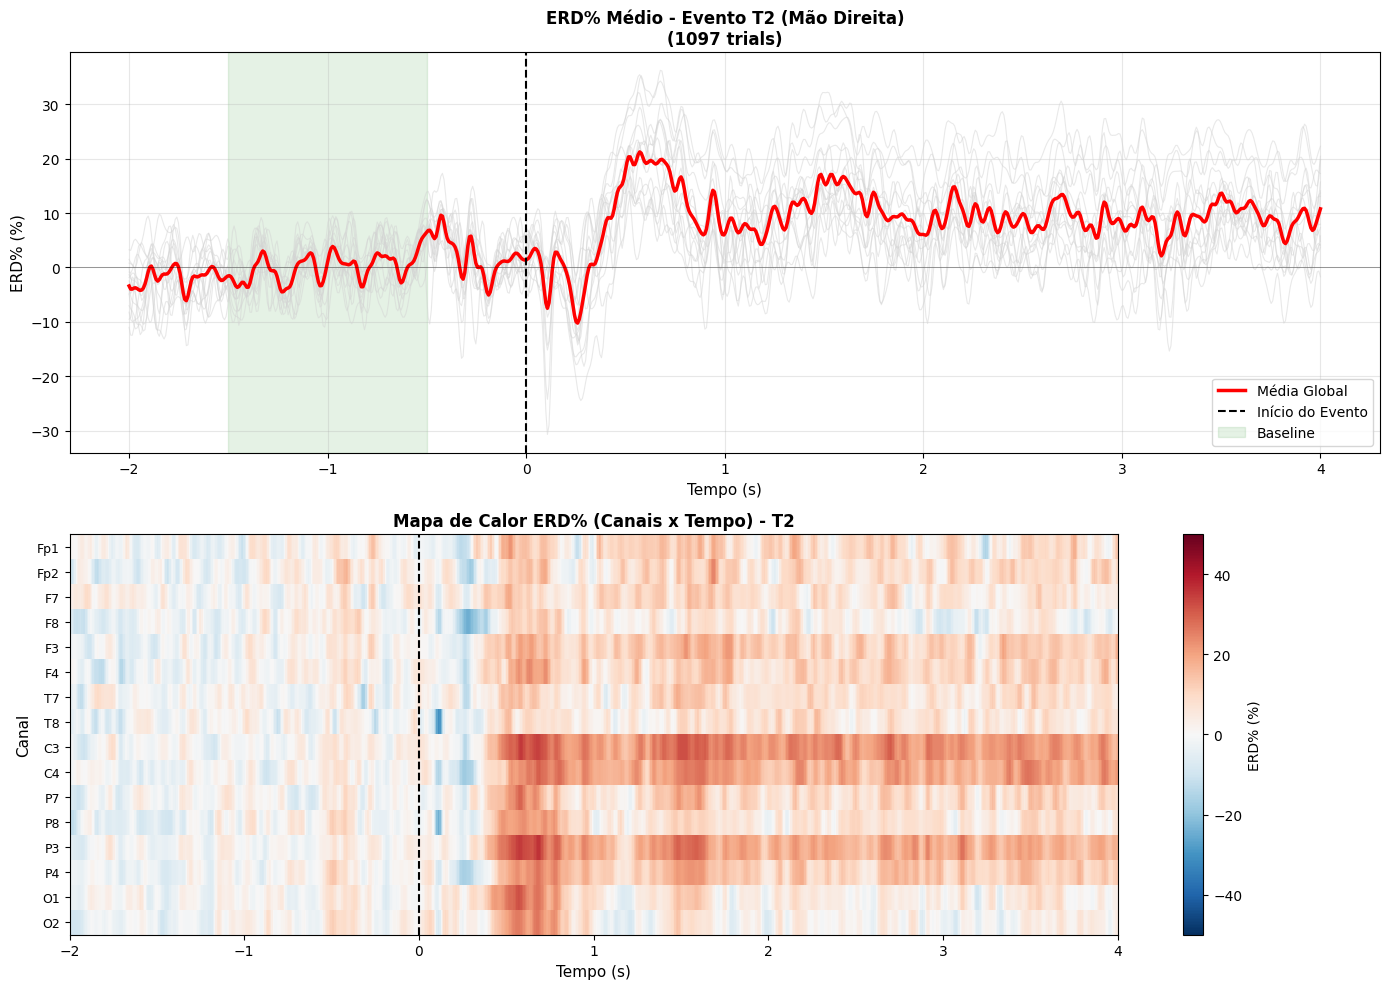

ERD% Média Global: 6.20%
ERD% Min: -30.69%
ERD% Max: 36.25%
ERD% Std: 8.66%


In [19]:
# Calcular e plotar ERD% = (R - A) / R
# R = Baseline (potência média no intervalo de baseline)
# A = Activity (potência média em cada ponto do tempo)
# Compara potência em dois momentos distintos

print("\n" + "="*60)
print("ANÁLISE ERD% = (Baseline - Activity) / Baseline")
print("="*60)

for event_type in ['T1', 'T2']:
    epoch_list = all_epochs[event_type]
    
    if not epoch_list:
        print(f"Nenhum dado encontrado para {event_type}")
        continue
    
    # Concatenar todos os trials
    combined_epochs = np.concatenate(epoch_list, axis=0)
    print(f"\n{event_type}: {combined_epochs.shape[0]} trials")
    
    # combined_epochs shape: (n_trials, n_samples, n_channels)
    n_trials, n_samples, n_channels = combined_epochs.shape
    
    # Calcular R: potência baseline (média de potência no intervalo de baseline)
    baseline_start = int((BASELINE_WINDOW[0] + T_PRE) * FS)
    baseline_end = int((BASELINE_WINDOW[1] + T_PRE) * FS)
    
    # R por canal (média sobre trials e tempo de baseline)
    R = np.mean(combined_epochs[:, baseline_start:baseline_end, :], axis=(0, 1))
    print(f"Baseline R shape: {R.shape}")
    
    # Calcular A: potência de atividade (média sobre trials em cada ponto do tempo)
    # A tem shape (n_samples, n_channels)
    A = np.mean(combined_epochs, axis=0)  # Média sobre trials
    
    # Calcular ERD% = (R - A) / R * 100
    # R é um vetor (n_channels,), A é uma matriz (n_samples, n_channels)
    # Broadcasting: R é expandido para cada ponto do tempo
    erd_percent = np.zeros((n_samples, n_channels))
    for ch in range(n_channels):
        if R[ch] > 0:
            erd_percent[:, ch] = ((R[ch] - A[:, ch]) / R[ch]) * 100
        else:
            erd_percent[:, ch] = 0
    
    print(f"ERD% calculated, shape: {erd_percent.shape}")
    print(f"R (Baseline) média por canal: {np.mean(R):.6f}")
    print(f"A (Activity) média geral: {np.mean(A):.6f}")
    
    # Plotar ERD%
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Gráfico 1: ERD% línea
    ax = axes[0]
    ax.plot(time_axis, erd_percent, color='lightgray', alpha=0.5, linewidth=0.8)
    ax.plot(time_axis, np.mean(erd_percent, axis=1), color='red', linewidth=2.5, label='Média Global')
    ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=1.5, label='Início do Evento')
    ax.axvspan(BASELINE_WINDOW[0], BASELINE_WINDOW[1], color='green', alpha=0.1, label='Baseline')
    ax.set_title(f'ERD% Médio - Evento {event_type} (Mão {"Esquerda" if event_type == "T1" else "Direita"})\n({combined_epochs.shape[0]} trials)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (s)', fontsize=11)
    ax.set_ylabel('ERD% (%)', fontsize=11)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Gráfico 2: Mapa de calor ERD% (Canais x Tempo)
    ax = axes[1]
    im = ax.imshow(erd_percent.T, aspect='auto', extent=[-T_PRE, T_POST, 15.5, -0.5], 
                    cmap='RdBu_r', vmin=-50, vmax=50, interpolation='nearest')
    cbar = plt.colorbar(im, ax=ax, label='ERD% (%)')
    ax.set_title(f'Mapa de Calor ERD% (Canais x Tempo) - {event_type}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Tempo (s)', fontsize=11)
    ax.set_ylabel('Canal', fontsize=11)
    ax.set_yticks(range(16))
    ax.set_yticklabels(['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'P7', 'P8', 'P3', 'P4', 'O1', 'O2'], fontsize=9)
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    
    plt.tight_layout()
    plt.show()
    
    # Estatísticas
    print(f"ERD% Média Global: {np.mean(erd_percent):.2f}%")
    print(f"ERD% Min: {np.min(erd_percent):.2f}%")
    print(f"ERD% Max: {np.max(erd_percent):.2f}%")
    print(f"ERD% Std: {np.std(erd_percent):.2f}%")

In [20]:
# Criar objeto MNE Epochs para análises subsequentes
print("\n" + "="*70)
print("CRIANDO OBJETOS MNE EPOCHS")
print("="*70)

mne_epochs = create_mne_epochs_from_processed_data(all_epochs)
print("\n✅ Objetos MNE Epochs criados com sucesso!")



CRIANDO OBJETOS MNE EPOCHS

✓ T1: 1108 trials
  - Duração: 6.00 s
  - Canais: 16
Not setting metadata
1108 matching events found
No baseline correction applied
0 projection items activated

✓ T2: 1097 trials
  - Duração: 6.00 s
  - Canais: 16
Not setting metadata
1097 matching events found
No baseline correction applied
0 projection items activated

✅ Objetos MNE Epochs criados com sucesso!


In [21]:
def create_mne_epochs_from_processed_data(all_epochs_dict, sfreq=125):
    """
    Cria objetos MNE Epochs a partir dos dados já processados.
    all_epochs_dict: dicionário com 'T1' e 'T2' contendo listas de arrays de épocas
    """
    mne_epochs = {}
    
    # Nomes dos canais EEG 10-20 standard
    ch_names = ['Fp1', 'Fp2', 'F7', 'F8', 'F3', 'F4', 'T7', 'T8', 'C3', 'C4', 'P7', 'P8', 'P3', 'P4', 'O1', 'O2']
    
    for event_type in ['T1', 'T2']:
        epoch_list = all_epochs_dict[event_type]
        
        if not epoch_list:
            print(f"⚠️ Nenhum dado para {event_type}")
            continue
        
        # Concatenar todas as épocas
        combined = np.concatenate(epoch_list, axis=0)  # Shape: (n_trials, n_samples, n_channels)
        
        print(f"\n✓ {event_type}: {combined.shape[0]} trials")
        print(f"  - Duração: {combined.shape[1] / sfreq:.2f} s")
        print(f"  - Canais: {combined.shape[2]}")
        
        # Criar informação dos canais
        ch_types = ['eeg'] * len(ch_names)
        info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
        
        # Transpose para formato MNE: (n_trials, n_channels, n_samples)
        data_mne = np.transpose(combined, (0, 2, 1))
        
        # Criar objeto Epochs
        events_array = np.array([[i, 0, 1] for i in range(len(data_mne))])
        event_id = {event_type: 1}
        
        epochs = mne.EpochsArray(data_mne, info, events_array, event_id=event_id)
        mne_epochs[event_type] = epochs
    
    return mne_epochs


🎯 Plotando dados com MNE...

VISUALIZAÇÃO - Evento T1

📊 Gerando gráficos para T1...


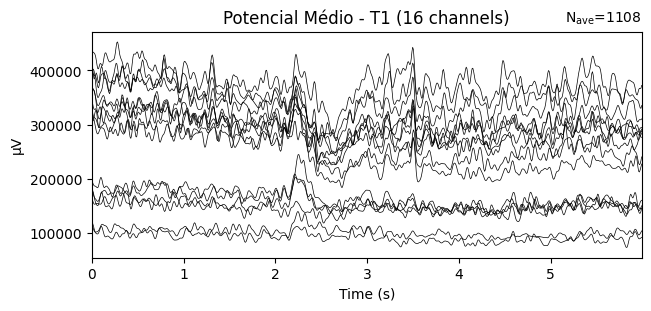

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Not setting metadata
1108 matching events found
No baseline correction applied
0 projection items activated


c:\Users\Chari\Documents\dev\BrainBridge\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


combining channels using "mean"


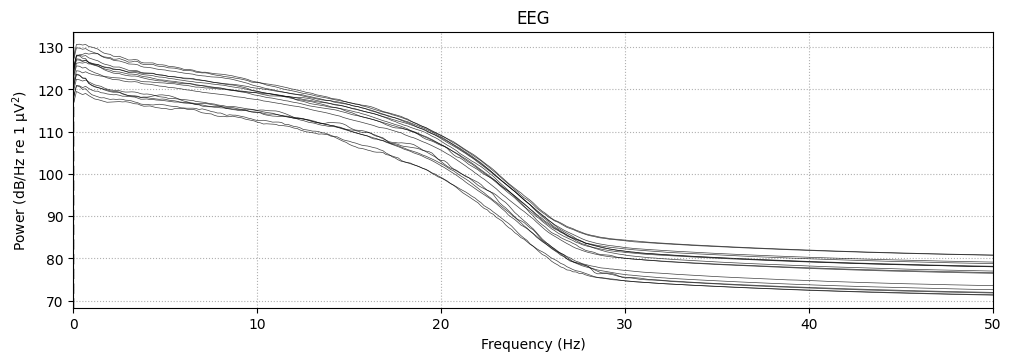

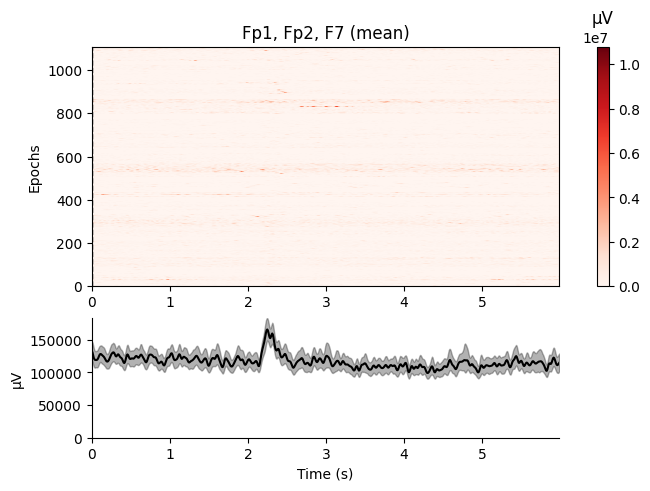

✅ Gráficos gerados para T1

VISUALIZAÇÃO - Evento T2

📊 Gerando gráficos para T2...


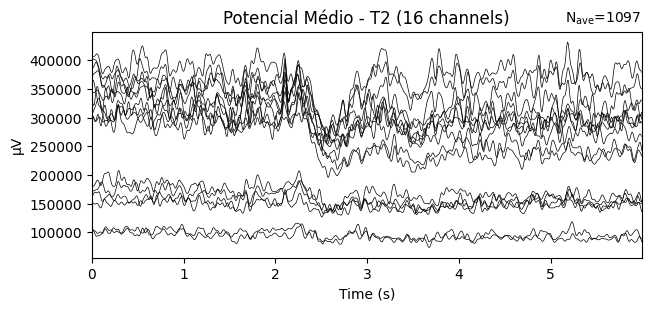

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
Not setting metadata
1097 matching events found
No baseline correction applied
0 projection items activated


c:\Users\Chari\Documents\dev\BrainBridge\.venv\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


combining channels using "mean"


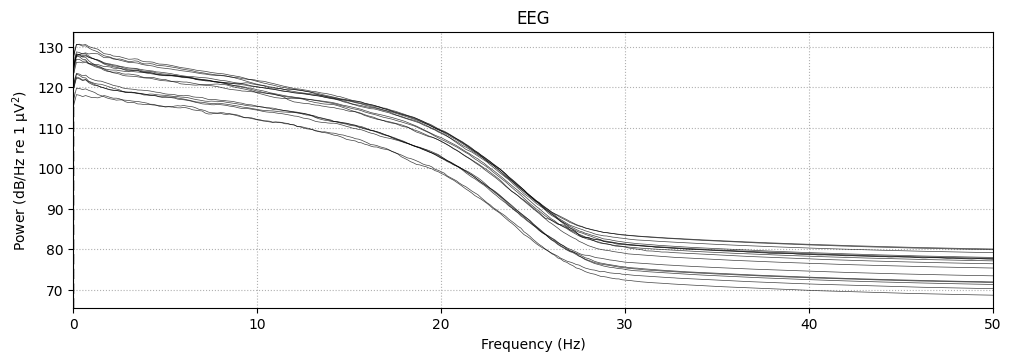

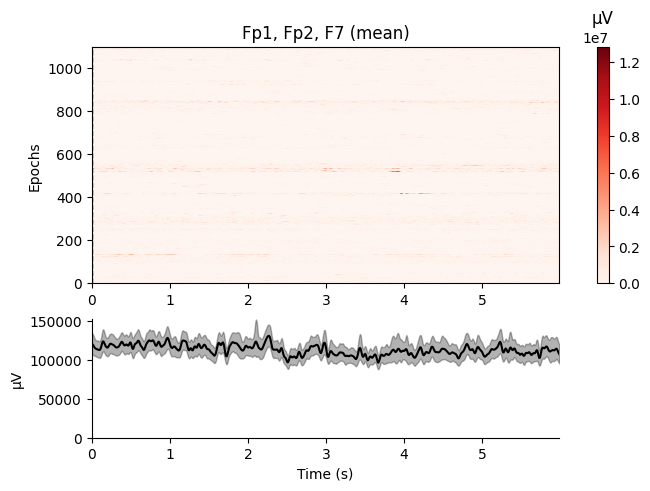

✅ Gráficos gerados para T2


In [22]:
# Plotar sinais e PSD com MNE

def plot_mne_epochs(mne_epochs_dict):
    """
    Plota os dados das épocas usando MNE
    """
    for event_type, epochs in mne_epochs_dict.items():
        print(f"\n{'='*70}")
        print(f"VISUALIZAÇÃO - Evento {event_type}")
        print(f"{'='*70}")
        
        # 1. Plotar sinais médios (ERP)
        print(f"\n📊 Gerando gráficos para {event_type}...")
        
        # Calcular a média das épocas
        evoked = epochs.average()
        
        # Plotar sinais
        fig = evoked.plot(titles=f'Potencial Médio - {event_type}')
        
        # 2. Plotar PSD
        psd_fig = epochs.plot_psd(fmin=0, fmax=50, spatial_colors=False)
        
        # 3. Imagem de todas as épocas
        fig_image = epochs.plot_image(combine='mean', picks=[0, 1, 2])
        
        print(f"✅ Gráficos gerados para {event_type}")

# Plotar os dados
if mne_epochs:
    print("\n🎯 Plotando dados com MNE...")
    plot_mne_epochs(mne_epochs)
else:
    print("⚠️ Nenhum dado disponível para plotar")


ANÁLISE DE BANDAS DE FREQUÊNCIA COM MNE

🎯 Analisando potência em diferentes bandas...

ANÁLISE POR BANDA - Evento T1

✓ Dados carregados: (1108, 16, 750)
  - Épocas: 1108
  - Canais: 16
  - Amostras: 750
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 825 samples (6.600 s)



C:\Users\Chari\AppData\Local\Temp\ipykernel_3600\950926500.py:38: RuntimeWarning: filter_length (825) is longer than the signal (750), distortion is likely. Reduce filter length or filter a longer signal.
  filtered_epochs.filter(l_freq=low_freq, h_freq=high_freq, picks='eeg')


Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 207 samples (1.656 s)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter 

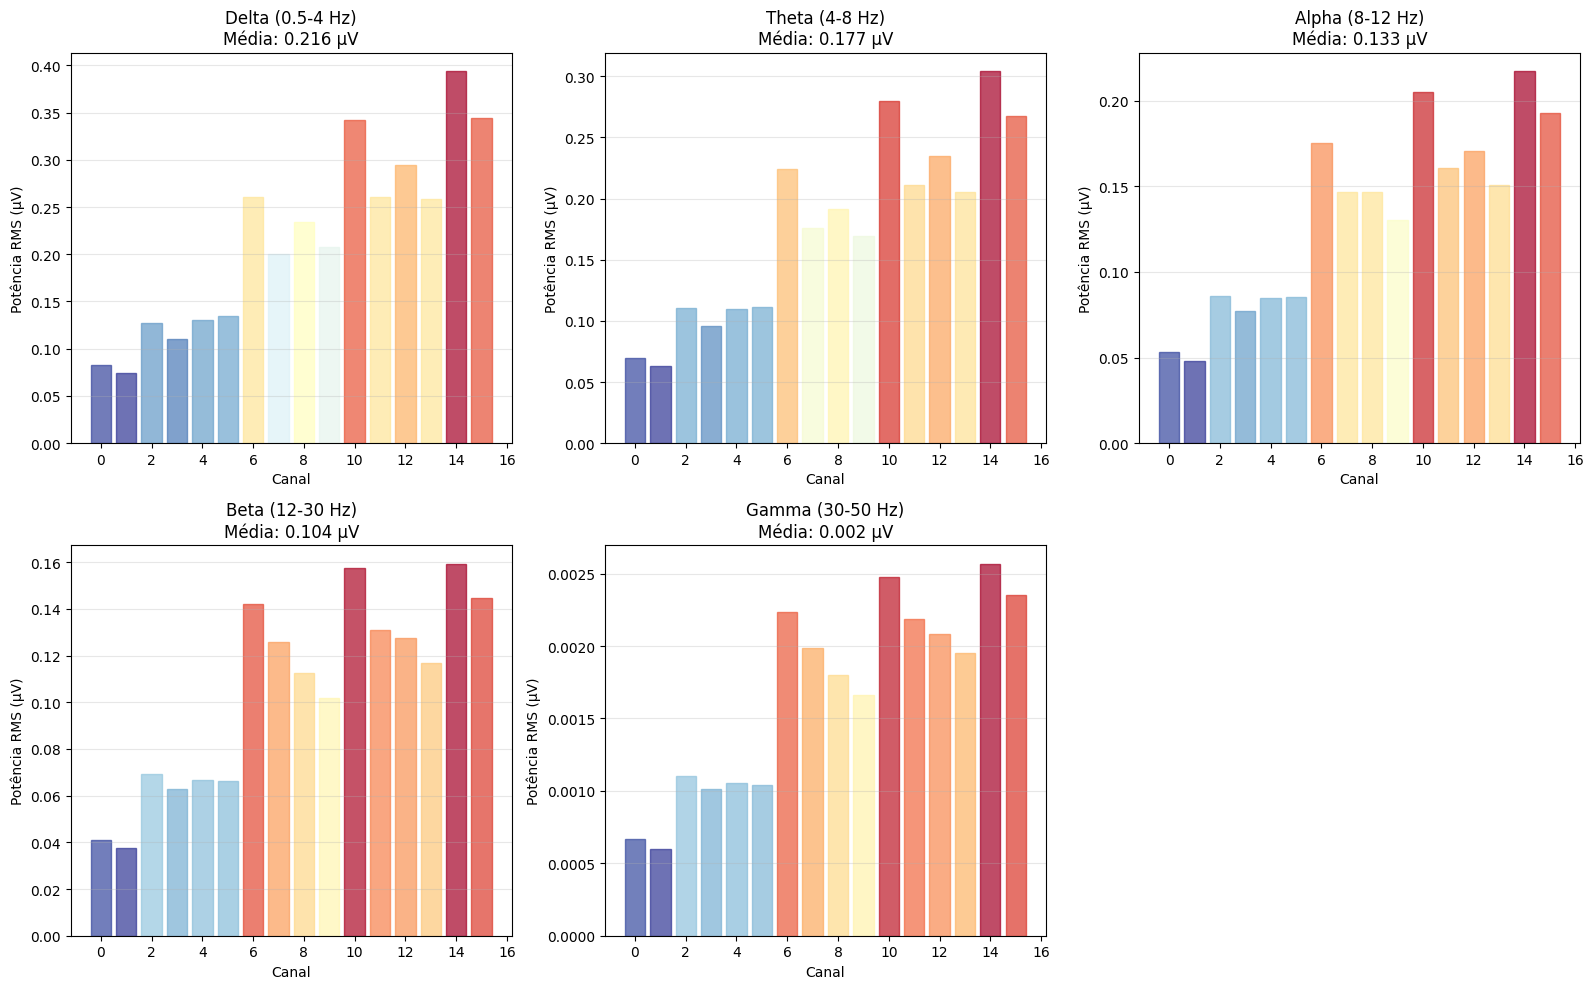


📊 Resumo de Potência por Banda - T1:
   Banda     | Média      | Min        | Max
   --------------------------------------------------
   Delta     |      0.216 |      0.074 |      0.394
   Theta     |      0.177 |      0.063 |      0.304
   Alpha     |      0.133 |      0.048 |      0.217
   Beta      |      0.104 |      0.038 |      0.159
   Gamma     |      0.002 |      0.001 |      0.003

ANÁLISE POR BANDA - Evento T2

✓ Dados carregados: (1097, 16, 750)
  - Épocas: 1097
  - Canais: 16
  - Amostras: 750
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter 

C:\Users\Chari\AppData\Local\Temp\ipykernel_3600\950926500.py:38: RuntimeWarning: filter_length (825) is longer than the signal (750), distortion is likely. Reduce filter length or filter a longer signal.
  filtered_epochs.filter(l_freq=low_freq, h_freq=high_freq, picks='eeg')


Setting up band-pass filter from 4 - 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 4.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 3.00 Hz)
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 207 samples (1.656 s)

Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter 

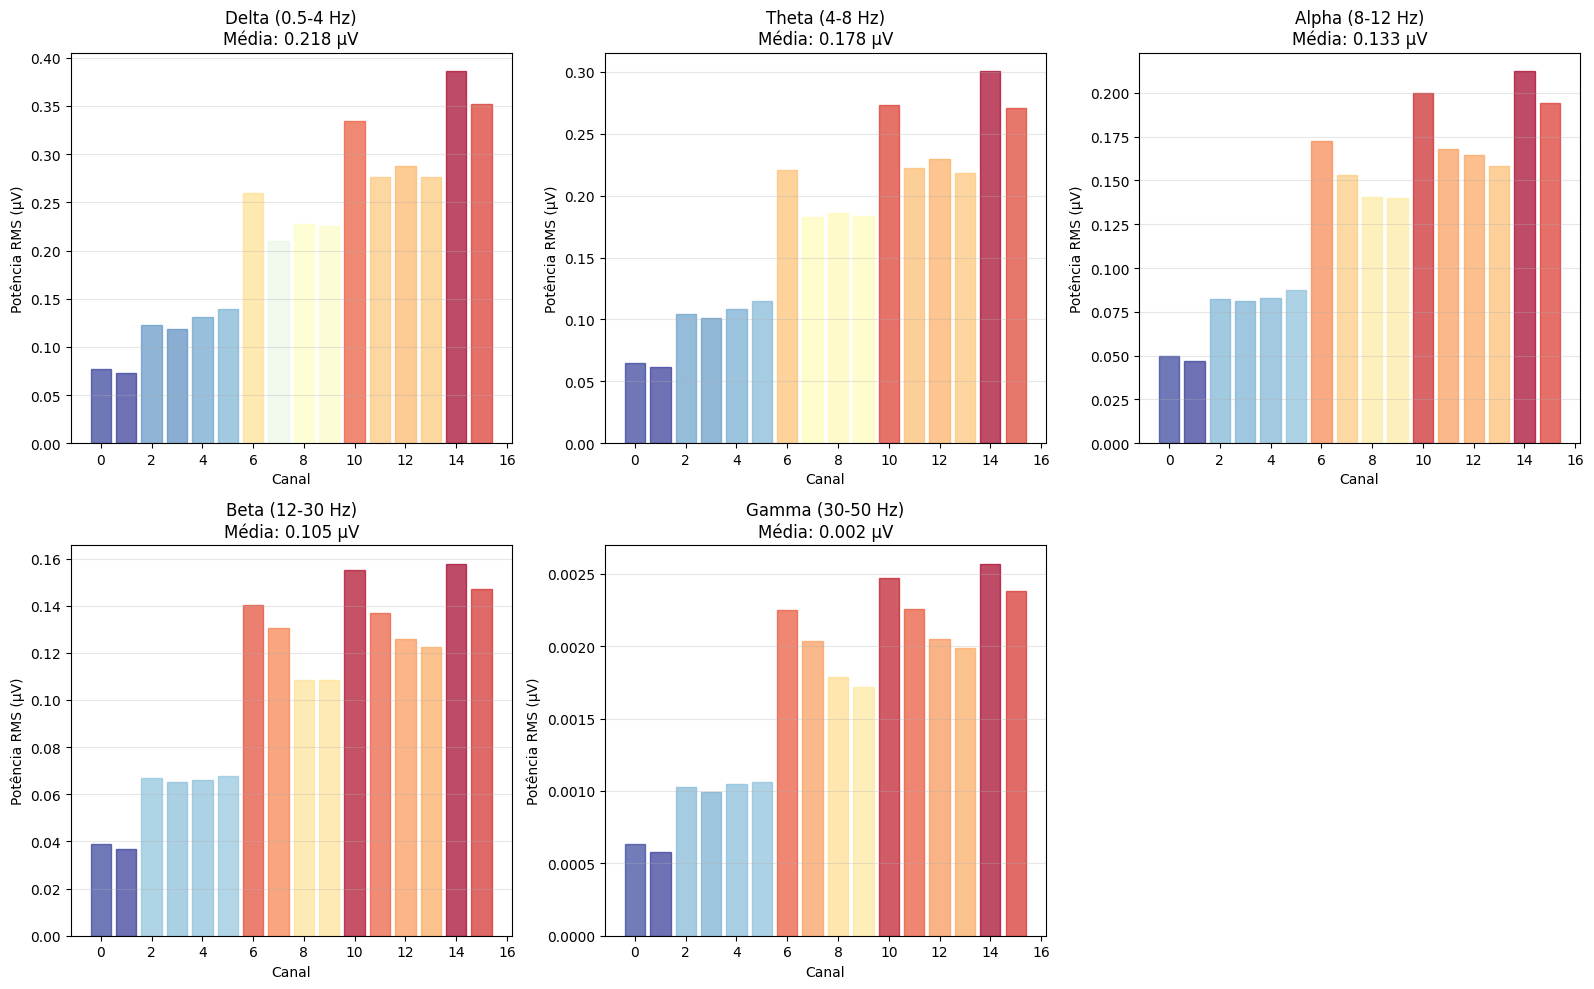


📊 Resumo de Potência por Banda - T2:
   Banda     | Média      | Min        | Max
   --------------------------------------------------
   Delta     |      0.218 |      0.073 |      0.386
   Theta     |      0.178 |      0.061 |      0.301
   Alpha     |      0.133 |      0.047 |      0.212
   Beta      |      0.105 |      0.037 |      0.158
   Gamma     |      0.002 |      0.001 |      0.003


In [23]:
# Análise ERD e topomaps por banda de frequência

def plot_topomap_by_band(mne_epochs_dict):
    """
    Plota topomaps de potência por banda de frequência
    """
    
    bands = {'Delta': (0.5, 4), 'Theta': (4, 8), 'Alpha': (8, 12), 
             'Beta': (12, 30), 'Gamma': (30, 50)}
    
    for event_type, epochs in mne_epochs_dict.items():
        print(f"\n{'='*70}")
        print(f"ANÁLISE POR BANDA - Evento {event_type}")
        print(f"{'='*70}")
        
        # Copiar epochs para não modificar os originais
        epochs_copy = epochs.copy()
        
        # Extrair dados brutos
        data = epochs_copy.get_data()  # Shape: (n_epochs, n_channels, n_samples)
        sfreq = epochs_copy.info['sfreq']
        
        print(f"\n✓ Dados carregados: {data.shape}")
        print(f"  - Épocas: {data.shape[0]}")
        print(f"  - Canais: {data.shape[1]}")
        print(f"  - Amostras: {data.shape[2]}")
        
        # Calcular potência média por banda
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        axes = axes.flatten()
        
        band_names = list(bands.keys())
        band_values_list = []
        
        for idx, (band_name, (low_freq, high_freq)) in enumerate(bands.items()):
            # Filtrar dados na banda
            filtered_epochs = epochs_copy.copy()
            filtered_epochs.filter(l_freq=low_freq, h_freq=high_freq, picks='eeg')
            
            # Calcular potência (RMS) por canal
            filtered_data = filtered_epochs.get_data()
            power_per_channel = np.mean(np.sqrt(np.mean(filtered_data ** 2, axis=2)), axis=0)
            band_values_list.append(power_per_channel)
            
            ax = axes[idx]
            
            # Plotar potência por canal
            im = ax.bar(range(len(power_per_channel)), power_per_channel, color='steelblue', alpha=0.7)
            ax.set_xlabel('Canal')
            ax.set_ylabel('Potência RMS (µV)')
            ax.set_title(f'{band_name} ({low_freq}-{high_freq} Hz)\nMédia: {np.mean(power_per_channel):.3f} µV')
            ax.grid(True, alpha=0.3, axis='y')
            
            # Colorir baseado na potência
            norm = plt.Normalize(vmin=power_per_channel.min(), vmax=power_per_channel.max())
            colors = plt.cm.RdYlBu_r(norm(power_per_channel))
            for bar, color in zip(im, colors):
                bar.set_color(color)
        
        # Remover último subplot
        fig.delaxes(axes[5])
        
        plt.tight_layout()
        plt.show()
        
        # Resumo estatístico
        print(f"\n📊 Resumo de Potência por Banda - {event_type}:")
        print("   Banda     | Média      | Min        | Max")
        print("   " + "-" * 50)
        for band_name, values in zip(band_names, band_values_list):
            print(f"   {band_name:9} | {np.mean(values):10.3f} | {np.min(values):10.3f} | {np.max(values):10.3f}")

# Executar análise por banda
print("\n" + "="*70)
print("ANÁLISE DE BANDAS DE FREQUÊNCIA COM MNE")
print("="*70)

if mne_epochs:
    print("\n🎯 Analisando potência em diferentes bandas...")
    plot_topomap_by_band(mne_epochs)
else:
    print("⚠️ Nenhum dado disponível")